# CDS change type alluvial (Ensembl → CAT)
Protein-coding only; grouped to 5 categories by default.

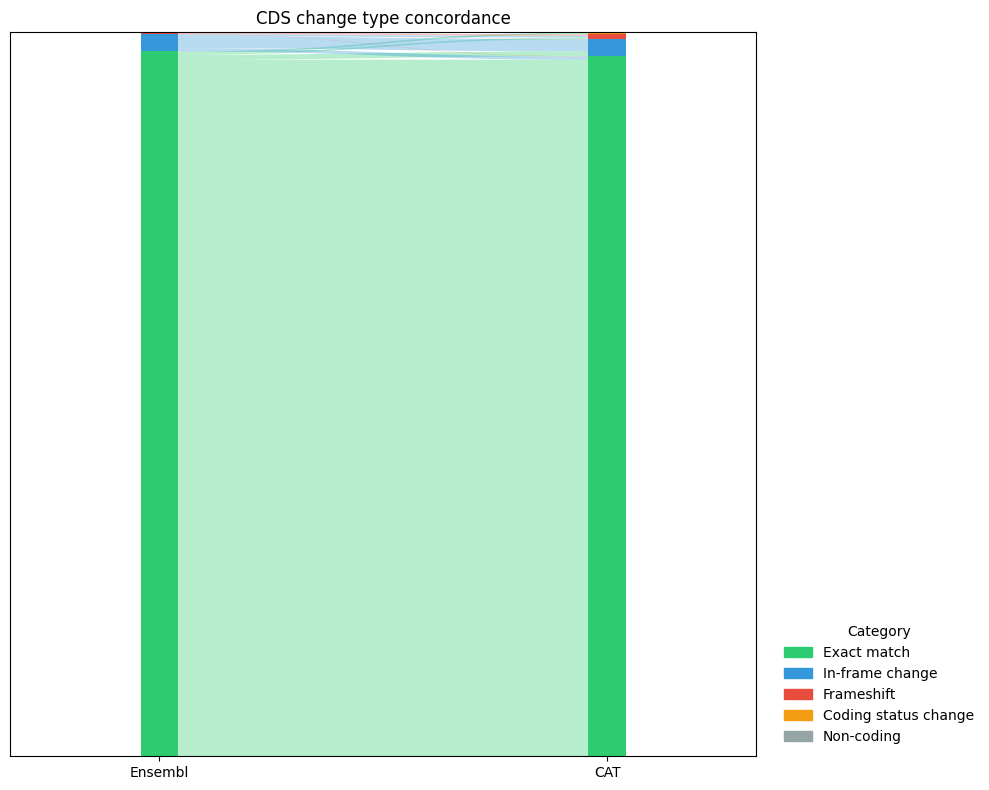

Saved figures/figure_main2_cds_alluvial_grouped.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPED = True  # toggle to False for 8-type view

GROUP_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
GROUP_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
GROUP_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Build grouped or ungrouped table
# ─────────────────────────────────────────────
if GROUPED:
    pc['ens_group'] = pc['ens_cds_change_type'].map(GROUP_MAP)
    pc['cat_group'] = pc['cat_cds_change_type'].map(GROUP_MAP)
    rows = pc.groupby(['ens_group', 'cat_group'])['count'].sum().reset_index()

    ens_labels = GROUP_ORDER.copy()
    cat_labels = GROUP_ORDER.copy()

    ens_color_map = GROUP_COLORS.copy()
    cat_color_map = GROUP_COLORS.copy()

    title = 'CDS change type concordance'
    EXACT = 'Exact match'
else:
    rows = pc.groupby(['ens_cds_change_type', 'cat_cds_change_type'])['count'].sum().reset_index()

    # Keep stable, readable ordering: ENS order first seen; CAT order first seen
    ens_labels = pd.Index(rows['ens_cds_change_type']).drop_duplicates().tolist()
    cat_labels = pd.Index(rows['cat_cds_change_type']).drop_duplicates().tolist()

    # Separate colour maps (so legends can differ). If you want distinct palettes, change these.
    ens_color_map = {k: '#3498db' for k in ens_labels}
    cat_color_map = {k: '#9b59b6' for k in cat_labels}

    title = 'CDS change type concordance (8 types, protein-coding)'
    EXACT = 'exact_match'

# ─────────────────────────────────────────────
# DROP exact→exact ONLY (keep exact on each side otherwise)
# ─────────────────────────────────────────────
# if GROUPED:
#     rows = rows[~((rows['ens_group'] == EXACT) & (rows['cat_group'] == EXACT))].copy()
# else:
#     rows = rows[~((rows['ens_cds_change_type'] == EXACT) &
#                   (rows['cat_cds_change_type'] == EXACT))].copy()

# ─────────────────────────────────────────────
# Pivot to matrix
# ─────────────────────────────────────────────
pivot = rows.pivot_table(index=rows.columns[0],
                         columns=rows.columns[1],
                         values='count',
                         fill_value=0)

pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

# ─────────────────────────────────────────────
# Compute cumulative ranges along y for the two vertical bars
# ─────────────────────────────────────────────
def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}

ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (now BOTH sides coloured by their own maps)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(
        x=X_ENS, height=hi-lo, width=BAR_W, bottom=lo,
        color=ens_color_map.get(lab, '#95a5a6'),
        align='center'
    )

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(
        x=X_CAT, height=hi-lo, width=BAR_W, bottom=lo,
        color=cat_color_map.get(lab, '#bdc3c7'),
        align='center'
    )

# ─────────────────────────────────────────────
# Ribbons
# ─────────────────────────────────────────────
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue

        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0

        verts = [
            (X_ENS + BAR_W/2, e_lo),
            (cx,             e_lo),
            (cx,             c_lo),
            (X_CAT - BAR_W/2, c_lo),
            (X_CAT - BAR_W/2, c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY,
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),  # colour by ENS category
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# ─────────────────────────────────────────────
# Axes / title
# ─────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
ax.set_title(title)

# ─────────────────────────────────────────────
# Two legends (ENS + CAT)
# ─────────────────────────────────────────────
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Ensembl category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

out = OUTPUT_DIR / (
    'figure_main2_cds_alluvial_grouped.png'
    if GROUPED else
    'figure_main2_cds_alluvial_ungrouped.png'
)

plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()

print('Saved', out)

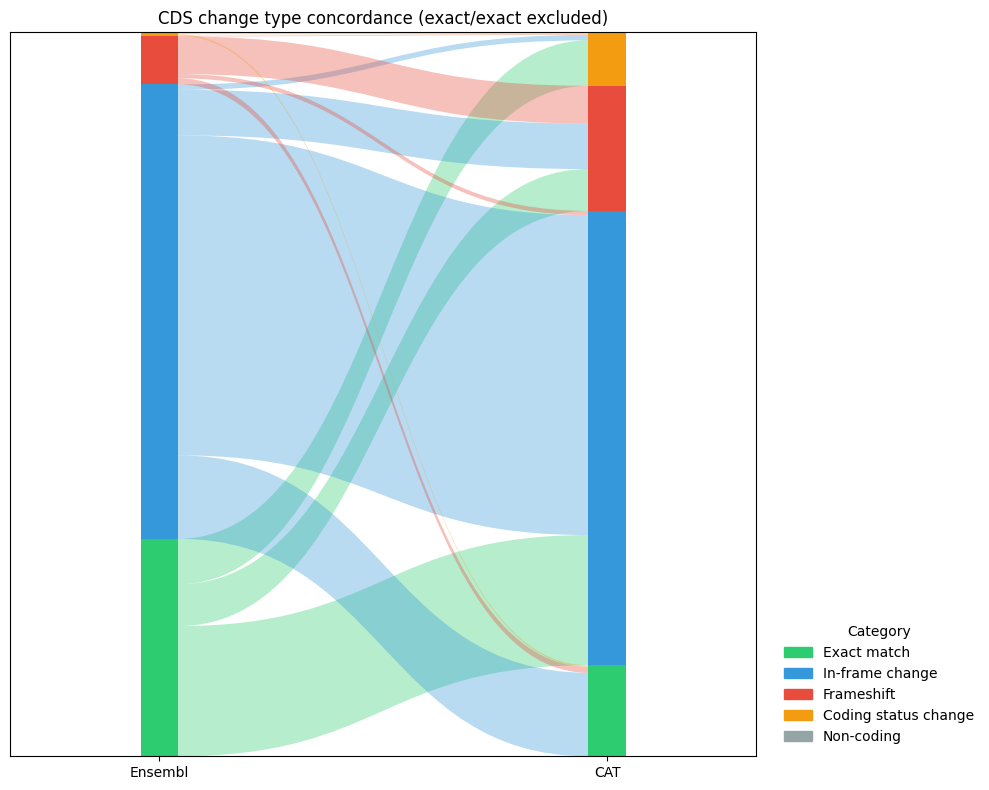

Saved figures/figure_main2_cds_alluvial_grouped_no_exact_exact_two_legends.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPED = True  # toggle to False for 8-type view

GROUP_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
GROUP_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
GROUP_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Build grouped or ungrouped table
# ─────────────────────────────────────────────
if GROUPED:
    pc['ens_group'] = pc['ens_cds_change_type'].map(GROUP_MAP)
    pc['cat_group'] = pc['cat_cds_change_type'].map(GROUP_MAP)
    rows = pc.groupby(['ens_group', 'cat_group'])['count'].sum().reset_index()

    ens_labels = GROUP_ORDER.copy()
    cat_labels = GROUP_ORDER.copy()

    ens_color_map = GROUP_COLORS.copy()
    cat_color_map = GROUP_COLORS.copy()

    title = 'CDS change type concordance'
    EXACT = 'Exact match'
else:
    rows = pc.groupby(['ens_cds_change_type', 'cat_cds_change_type'])['count'].sum().reset_index()

    # Keep stable, readable ordering: ENS order first seen; CAT order first seen
    ens_labels = pd.Index(rows['ens_cds_change_type']).drop_duplicates().tolist()
    cat_labels = pd.Index(rows['cat_cds_change_type']).drop_duplicates().tolist()

    # Separate colour maps (so legends can differ). If you want distinct palettes, change these.
    ens_color_map = {k: '#3498db' for k in ens_labels}
    cat_color_map = {k: '#9b59b6' for k in cat_labels}

    title = 'CDS change type concordance'
    EXACT = 'exact_match'

# ─────────────────────────────────────────────
# DROP exact→exact ONLY (keep exact on each side otherwise)
# ─────────────────────────────────────────────
if GROUPED:
    rows = rows[~((rows['ens_group'] == EXACT) & (rows['cat_group'] == EXACT))].copy()
else:
    rows = rows[~((rows['ens_cds_change_type'] == EXACT) &
                  (rows['cat_cds_change_type'] == EXACT))].copy()

# ─────────────────────────────────────────────
# Pivot to matrix
# ─────────────────────────────────────────────
pivot = rows.pivot_table(index=rows.columns[0],
                         columns=rows.columns[1],
                         values='count',
                         fill_value=0)

pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

# ─────────────────────────────────────────────
# Compute cumulative ranges along y for the two vertical bars
# ─────────────────────────────────────────────
def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}

ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (now BOTH sides coloured by their own maps)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(
        x=X_ENS, height=hi-lo, width=BAR_W, bottom=lo,
        color=ens_color_map.get(lab, '#95a5a6'),
        align='center'
    )

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(
        x=X_CAT, height=hi-lo, width=BAR_W, bottom=lo,
        color=cat_color_map.get(lab, '#bdc3c7'),
        align='center'
    )

# ─────────────────────────────────────────────
# Ribbons
# ─────────────────────────────────────────────
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue

        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0

        verts = [
            (X_ENS + BAR_W/2, e_lo),
            (cx,             e_lo),
            (cx,             c_lo),
            (X_CAT - BAR_W/2, c_lo),
            (X_CAT - BAR_W/2, c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY,
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),  # colour by ENS category
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# ─────────────────────────────────────────────
# Axes / title
# ─────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
ax.set_title(title + " (exact/exact excluded)")

# ─────────────────────────────────────────────
# Two legends (ENS + CAT)
# ─────────────────────────────────────────────
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Ensembl category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

out = OUTPUT_DIR / (
    'figure_main2_cds_alluvial_grouped_no_exact_exact_two_legends.png'
    if GROUPED else
    'figure_main2_cds_alluvial_ungrouped_no_exact_exact_two_legends.png'
)

plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()

print('Saved', out)

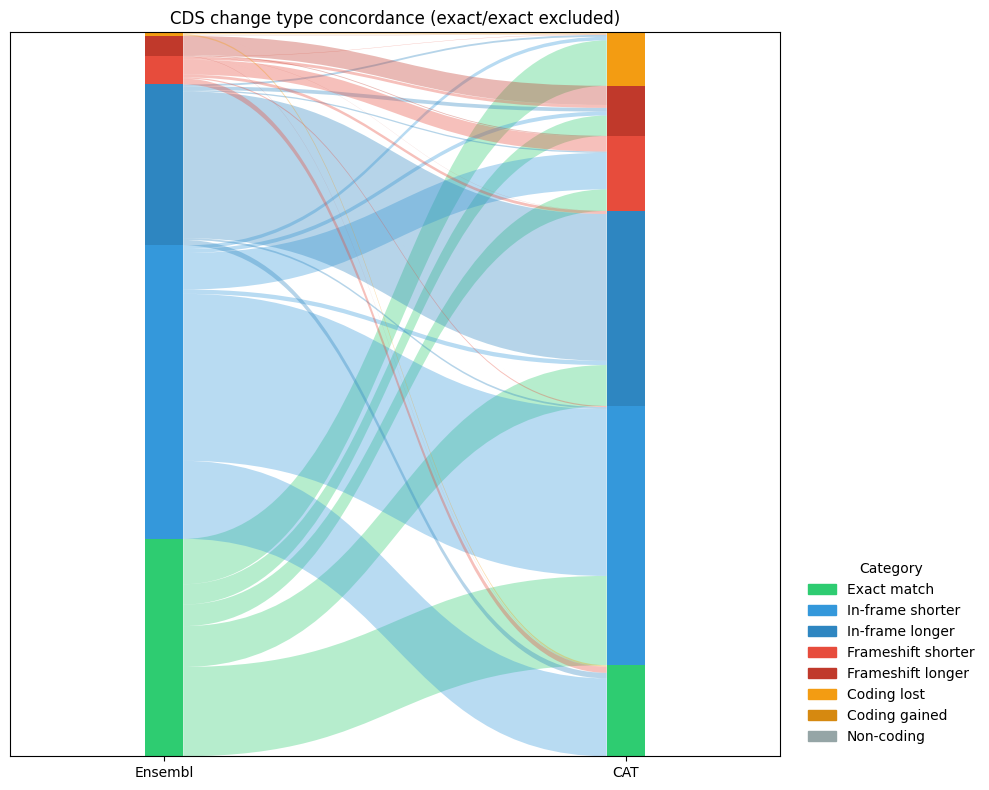

Saved figures/figure_main2_cds_alluvial_granular_two_legends.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# Controls
# ─────────────────────────────────────────────
GROUPING_MODE = "granular"   # "coarse" | "granular" | "raw"
DROP_EXACT_EXACT = True

# ─────────────────────────────────────────────
# Label maps + ordering + colours
# ─────────────────────────────────────────────
COARSE_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
COARSE_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
COARSE_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

GRANULAR_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame shorter',
    'in_frame_longer':    'In-frame longer',
    'frameshift_shorter': 'Frameshift shorter',
    'frameshift_longer':  'Frameshift longer',
    'coding_lost':        'Coding lost',
    'coding_gained':      'Coding gained',
    'non_coding':         'Non-coding',
}
GRANULAR_ORDER = [
    'Exact match',
    'In-frame shorter', 'In-frame longer',
    'Frameshift shorter', 'Frameshift longer',
    'Coding lost', 'Coding gained',
    'Non-coding'
]
# Choose colours that are still “family consistent” (same hue families as coarse)
GRANULAR_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame shorter':     '#3498db',
    'In-frame longer':      '#2e86c1',
    'Frameshift shorter':   '#e74c3c',
    'Frameshift longer':    '#c0392b',
    'Coding lost':          '#f39c12',
    'Coding gained':        '#d68910',
    'Non-coding':           '#95a5a6',
}

# ─────────────────────────────────────────────
# Load
# ─────────────────────────────────────────────
ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Apply grouping mode
# ─────────────────────────────────────────────
if GROUPING_MODE == "coarse":
    label_map = COARSE_MAP
    order = COARSE_ORDER
    ens_color_map = COARSE_COLORS
    cat_color_map = COARSE_COLORS
    ens_key, cat_key = "ens_group", "cat_group"
    pc[ens_key] = pc["ens_cds_change_type"].map(label_map)
    pc[cat_key] = pc["cat_cds_change_type"].map(label_map)
    title = "CDS change type concordance (coarse grouped, protein-coding)"
    EXACT_LABEL = "Exact match"

elif GROUPING_MODE == "granular":
    label_map = GRANULAR_MAP
    order = GRANULAR_ORDER
    ens_color_map = GRANULAR_COLORS
    cat_color_map = GRANULAR_COLORS
    ens_key, cat_key = "ens_group", "cat_group"
    pc[ens_key] = pc["ens_cds_change_type"].map(label_map)
    pc[cat_key] = pc["cat_cds_change_type"].map(label_map)
    title = "CDS change type concordance"
    EXACT_LABEL = "Exact match"

elif GROUPING_MODE == "raw":
    ens_key, cat_key = "ens_cds_change_type", "cat_cds_change_type"
    # stable order = first-seen in the data
    order_ens = pd.Index(pc[ens_key]).drop_duplicates().tolist()
    order_cat = pd.Index(pc[cat_key]).drop_duplicates().tolist()
    # separate palettes so two legends aren’t identical (edit if you want)
    ens_color_map = {k: '#3498db' for k in order_ens}
    cat_color_map = {k: '#9b59b6' for k in order_cat}
    title = "CDS change type concordance"
    EXACT_LABEL = "exact_match"

else:
    raise ValueError("GROUPING_MODE must be: 'coarse', 'granular', or 'raw'")

# ─────────────────────────────────────────────
# Aggregate
# ─────────────────────────────────────────────
rows = pc.groupby([ens_key, cat_key], dropna=False)['count'].sum().reset_index()

# Decide labels per side
if GROUPING_MODE in ("coarse", "granular"):
    ens_labels = order.copy()
    cat_labels = order.copy()
else:
    ens_labels = order_ens
    cat_labels = order_cat

# Drop exact→exact only (optional)
if DROP_EXACT_EXACT:
    rows = rows[~((rows[ens_key] == EXACT_LABEL) & (rows[cat_key] == EXACT_LABEL))].copy()

# Pivot and reindex to get full matrix with zeros
pivot = rows.pivot_table(index=ens_key, columns=cat_key, values='count', fill_value=0)
pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}
ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (both sides coloured)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(X_ENS, hi-lo, width=BAR_W, bottom=lo, color=ens_color_map.get(lab, '#95a5a6'), align='center')

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(X_CAT, hi-lo, width=BAR_W, bottom=lo, color=cat_color_map.get(lab, '#bdc3c7'), align='center')

# Ribbons
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue
        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0
        verts = [
            (X_ENS + BAR_W/2,  e_lo),
            (cx,              e_lo),
            (cx,              c_lo),
            (X_CAT - BAR_W/2,  c_lo),
            (X_CAT - BAR_W/2,  c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# Axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
suffix = " (exact/exact excluded)" if DROP_EXACT_EXACT else ""
ax.set_title(title + suffix)

# Two legends
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

mode_tag = GROUPING_MODE
out = OUTPUT_DIR / f'figure_main2_cds_alluvial_{mode_tag}_two_legends.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print("Saved", out)

/tmp/ipykernel_1078473/4199480845.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


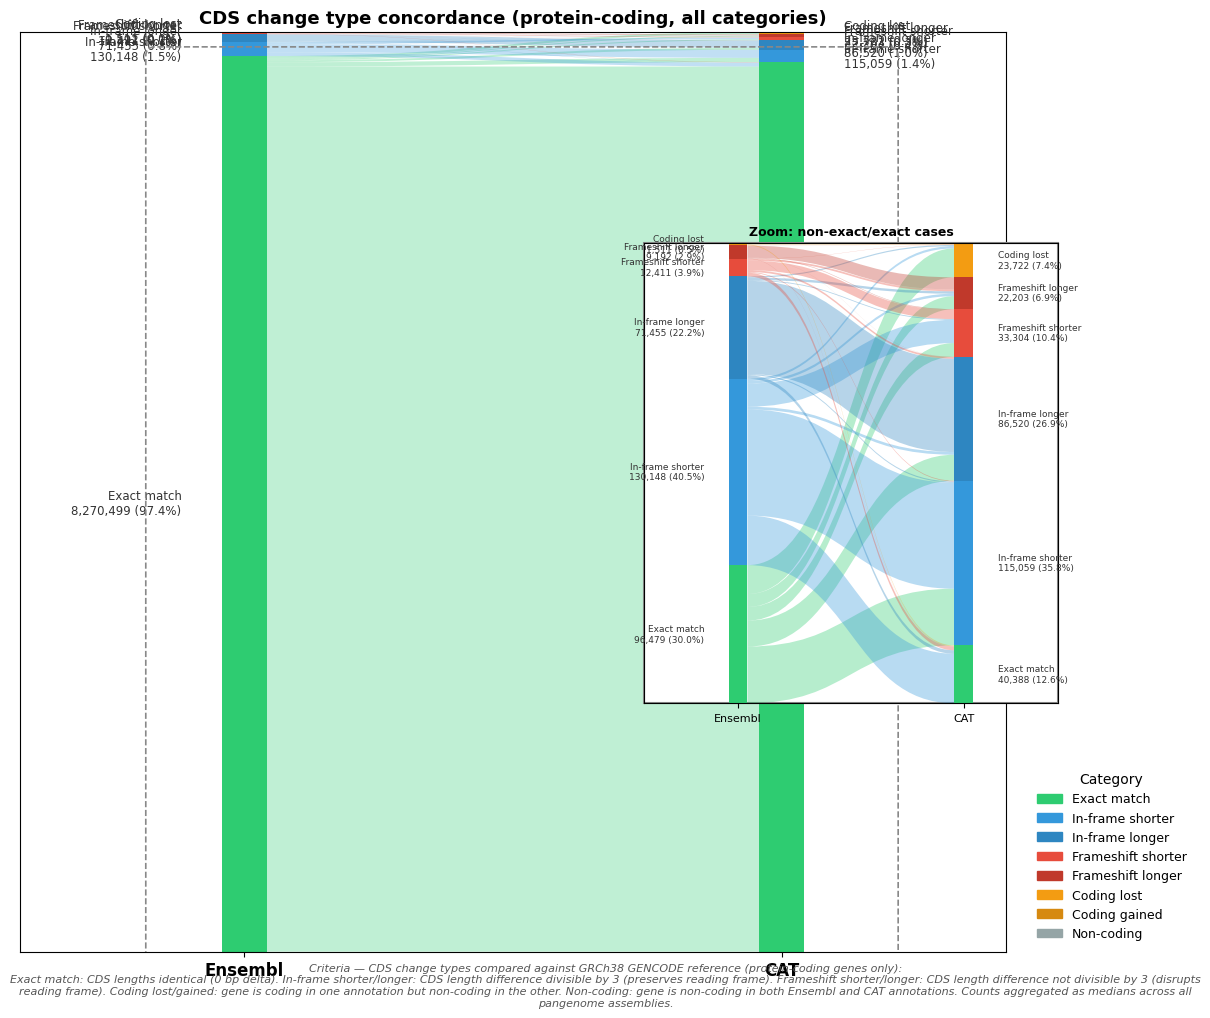

Saved to figures/figure_main2_cds_alluvial_full_with_inset.png
Saved to figures/figure_main2_cds_alluvial_full_with_inset.pdf


In [4]:
# --- Full alluvial with inset (including exact-exact) + Y-axis labels ---
# Main panel: complete picture (exact-exact dominates).
# Inset panel: zoomed to non-exact-exact cases (the interesting differences).

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# Labels, ordering, colours (granular mode)
# ─────────────────────────────────────────────
GRANULAR_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame shorter',
    'in_frame_longer':    'In-frame longer',
    'frameshift_shorter': 'Frameshift shorter',
    'frameshift_longer':  'Frameshift longer',
    'coding_lost':        'Coding lost',
    'coding_gained':      'Coding gained',
    'non_coding':         'Non-coding',
}
GRANULAR_ORDER = [
    'Exact match',
    'In-frame shorter', 'In-frame longer',
    'Frameshift shorter', 'Frameshift longer',
    'Coding lost', 'Coding gained',
    'Non-coding',
]
GRANULAR_COLORS = {
    'Exact match':        '#2ecc71',
    'In-frame shorter':   '#3498db',
    'In-frame longer':    '#2e86c1',
    'Frameshift shorter': '#e74c3c',
    'Frameshift longer':  '#c0392b',
    'Coding lost':        '#f39c12',
    'Coding gained':      '#d68910',
    'Non-coding':         '#95a5a6',
}

# ─────────────────────────────────────────────
# Load + prepare
# ─────────────────────────────────────────────
ct = pd.read_csv(DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv', sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()
pc['ens_group'] = pc['ens_cds_change_type'].map(GRANULAR_MAP)
pc['cat_group'] = pc['cat_cds_change_type'].map(GRANULAR_MAP)

rows_full = pc.groupby(['ens_group', 'cat_group'], dropna=False)['count'].sum().reset_index()
rows_inset = rows_full[
    ~((rows_full['ens_group'] == 'Exact match') & (rows_full['cat_group'] == 'Exact match'))
].copy()

ens_labels = GRANULAR_ORDER.copy()
cat_labels = GRANULAR_ORDER.copy()


# ─────────────────────────────────────────────
# Alluvial drawing helper
# ─────────────────────────────────────────────
def draw_alluvial(ax, rows, ens_labels, cat_labels, color_map,
                  show_y_labels=True, fontsize_label=8, ribbon_alpha=0.35,
                  x_ens=0.2, x_cat=0.8, bar_w=0.05, label_offset=0.07):
    """Draw a two-column alluvial on *ax* and return (ens_ranges, cat_ranges, grand_total)."""

    pivot = rows.pivot_table(index='ens_group', columns='cat_group', values='count', fill_value=0)
    pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
    grand_total = float(pivot.values.sum())
    if grand_total == 0:
        return {}, {}, 0

    def cumulative_ranges(totals, gt):
        rng, cursor = {}, 0.0
        for lab, v in totals.items():
            f = float(v) / gt if gt > 0 else 0.0
            rng[lab] = (cursor, cursor + f)
            cursor += f
        return rng

    ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
    cat_totals = {lab: float(pivot[lab].sum()) if lab in pivot.columns else 0.0 for lab in cat_labels}
    ens_ranges = cumulative_ranges(ens_totals, grand_total)
    cat_ranges = cumulative_ranges(cat_totals, grand_total)

    # Bars
    for lab, (lo, hi) in ens_ranges.items():
        if hi - lo <= 0:
            continue
        ax.bar(x_ens, hi - lo, width=bar_w, bottom=lo,
               color=color_map.get(lab, '#95a5a6'), align='center')

    for lab, (lo, hi) in cat_ranges.items():
        if hi - lo <= 0:
            continue
        ax.bar(x_cat, hi - lo, width=bar_w, bottom=lo,
               color=color_map.get(lab, '#bdc3c7'), align='center')

    # Y-axis labels (counts + proportions)
    if show_y_labels:
        for lab, (lo, hi) in ens_ranges.items():
            cnt = int(round(ens_totals[lab]))
            if cnt == 0:
                continue
            pct = cnt / grand_total * 100
            ax.text(x_ens - label_offset, (lo + hi) / 2,
                    f'{lab}\n{cnt:,} ({pct:.1f}%)',
                    ha='right', va='center', fontsize=fontsize_label,
                    color='#333333')

        for lab, (lo, hi) in cat_ranges.items():
            cnt = int(round(cat_totals[lab]))
            if cnt == 0:
                continue
            pct = cnt / grand_total * 100
            ax.text(x_cat + label_offset, (lo + hi) / 2,
                    f'{lab}\n{cnt:,} ({pct:.1f}%)',
                    ha='left', va='center', fontsize=fontsize_label,
                    color='#333333')

    # Ribbons (Bezier curves)
    ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
    cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

    for e in ens_labels:
        for c in cat_labels:
            if e not in pivot.index or c not in pivot.columns:
                continue
            cnt = float(pivot.loc[e, c])
            if cnt <= 0:
                continue
            frac = cnt / grand_total if grand_total > 0 else 0.0

            e_lo = ens_cursor[e]
            e_hi = e_lo + frac
            c_lo = cat_cursor[c]
            c_hi = c_lo + frac
            ens_cursor[e] = e_hi
            cat_cursor[c] = c_hi

            cx = (x_ens + x_cat) / 2.0
            verts = [
                (x_ens + bar_w / 2, e_lo),
                (cx, e_lo), (cx, c_lo), (x_cat - bar_w / 2, c_lo),
                (x_cat - bar_w / 2, c_hi),
                (cx, c_hi), (cx, e_hi), (x_ens + bar_w / 2, e_hi),
                (x_ens + bar_w / 2, e_lo),
            ]
            codes = [
                MplPath.MOVETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.LINETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.CLOSEPOLY,
            ]
            ax.add_patch(PathPatch(
                MplPath(verts, codes),
                facecolor=color_map.get(e, '#95a5a6'),
                edgecolor='none', alpha=ribbon_alpha, zorder=0,
            ))

    return ens_ranges, cat_ranges, grand_total


# ─────────────────────────────────────────────
# Main figure + inset
# ─────────────────────────────────────────────
fig, ax_main = plt.subplots(figsize=(12, 10))

ens_r, cat_r, total_full = draw_alluvial(
    ax_main, rows_full, ens_labels, cat_labels, GRANULAR_COLORS,
    show_y_labels=True, fontsize_label=8.5, ribbon_alpha=0.30,
)

ax_main.set_xlim(-0.05, 1.05)
ax_main.set_ylim(0, 1)
ax_main.set_xticks([0.2, 0.8])
ax_main.set_xticklabels(['Ensembl', 'CAT'], fontsize=12, fontweight='bold')
ax_main.set_yticks([])
ax_main.set_title('CDS change type concordance (protein-coding, all categories)',
                   fontsize=13, fontweight='bold')

# Legend
handles = [mpatches.Patch(color=GRANULAR_COLORS[lab], label=lab) for lab in GRANULAR_ORDER]
ax_main.legend(handles=handles, title='Category', loc='lower left',
               bbox_to_anchor=(1.02, 0.0), frameon=False, fontsize=9)

# ── Inset (non-exact-exact zoom) ──
ax_inset = inset_axes(ax_main, width="42%", height="50%",
                      loc='center right',
                      bbox_to_anchor=(0.06, 0.02, 1, 1),
                      bbox_transform=ax_main.transAxes)

# For the inset, use labels that actually appear in the subset
inset_ens_labels = [l for l in GRANULAR_ORDER
                    if l in rows_inset['ens_group'].values or l in rows_inset['cat_group'].values]
inset_cat_labels = inset_ens_labels  # same set

draw_alluvial(
    ax_inset, rows_inset, inset_ens_labels, inset_cat_labels, GRANULAR_COLORS,
    show_y_labels=True, fontsize_label=6.5, ribbon_alpha=0.35,
    label_offset=0.09,
)

ax_inset.set_xlim(-0.05, 1.05)
ax_inset.set_ylim(0, 1)
ax_inset.set_xticks([0.2, 0.8])
ax_inset.set_xticklabels(['Ensembl', 'CAT'], fontsize=8)
ax_inset.set_yticks([])
ax_inset.set_title('Zoom: non-exact/exact cases', fontsize=9, fontweight='bold')
ax_inset.patch.set_edgecolor('#888888')
ax_inset.patch.set_linewidth(1.5)

# Indicate zoom region on main plot — draw a dashed rectangle around the
# non-exact-match region (everything except the exact-match bar segment)
if 'Exact match' in ens_r:
    exact_top = ens_r['Exact match'][1]
    # The non-exact region spans from 0 to the bottom of exact-match
    rect = matplotlib.patches.FancyBboxPatch(
        (0.10, 0), 0.82, exact_top,
        boxstyle='round,pad=0.01',
        edgecolor='#888888', facecolor='none',
        linestyle='--', linewidth=1.2, zorder=3,
    )
    ax_main.add_patch(rect)

# ── Criteria text ──
criteria = (
    "Criteria — CDS change types compared against GRCh38 GENCODE reference (protein-coding genes only):\n"
    "Exact match: CDS lengths identical (0 bp delta). "
    "In-frame shorter/longer: CDS length difference divisible by 3 (preserves reading frame). "
    "Frameshift shorter/longer: CDS length difference not divisible by 3 (disrupts reading frame). "
    "Coding lost/gained: gene is coding in one annotation but non-coding in the other. "
    "Non-coding: gene is non-coding in both Ensembl and CAT annotations. "
    "Counts aggregated as medians across all pangenome assemblies."
)
fig.text(0.5, -0.01, criteria, ha='center', fontsize=8, color='#555555',
         style='italic', wrap=True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_main2_cds_alluvial_full_with_inset.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_main2_cds_alluvial_full_with_inset.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_main2_cds_alluvial_full_with_inset.png'}")
print(f"Saved to {OUTPUT_DIR / 'figure_main2_cds_alluvial_full_with_inset.pdf'}")

In [5]:
# --- Problematic genes TSV export ---
# Genes in the "inset" panel: non-exact/exact CDS change types (protein-coding only).
# Requires links_per_assembly.tsv with ens_cds_change_type / cat_cds_change_type columns
# (added to aggregate_concordance_vs_grch38.py).

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
LINKS_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'sankey_plus_divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# Load per-gene links (with CDS change type columns)
# ─────────────────────────────────────────────
links = pd.read_csv(LINKS_DIR / 'links_per_assembly.tsv', sep='\t', dtype=str)
print(f"Loaded {len(links):,} rows from links_per_assembly.tsv")
print(f"Columns: {list(links.columns)}")

# Check that the new columns exist
required = {'ens_cds_change_type', 'cat_cds_change_type'}
if not required.issubset(links.columns):
    raise RuntimeError(
        f"Missing columns {required - set(links.columns)} in links_per_assembly.tsv. "
        "Re-run the AGGREGATE_CONCORDANCE_VS_REF pipeline step after updating "
        "aggregate_concordance_vs_grch38.py to include these columns."
    )

# ─────────────────────────────────────────────
# Filter to problematic genes
# ─────────────────────────────────────────────
# Criteria: protein-coding genes where the (Ensembl, CAT) CDS change type pair
# is NOT (exact_match, exact_match) — i.e., at least one side diverges from
# GRCh38 or the two annotations disagree in CDS structure.
problematic = links[
    (links['biotype'] == 'protein_coding') &
    ~(
        (links['ens_cds_change_type'] == 'exact_match') &
        (links['cat_cds_change_type'] == 'exact_match')
    )
].copy()

print(f"\nProblematic (non-exact/exact) protein-coding genes: {len(problematic):,} rows")
print(f"Unique gene pairs: {problematic['pair_key'].nunique():,}")
print(f"Across assemblies: {problematic['assembly_accession'].nunique():,}")

# ─────────────────────────────────────────────
# Summary cross-tab of CDS change type pairs
# ─────────────────────────────────────────────
print("\n--- CDS change type pair counts (top 20) ---")
pair_counts = (
    problematic
    .groupby(['ens_cds_change_type', 'cat_cds_change_type'])
    .size()
    .reset_index(name='n_gene_assembly_pairs')
    .sort_values('n_gene_assembly_pairs', ascending=False)
)
print(pair_counts.head(20).to_string(index=False))

# ─────────────────────────────────────────────
# Export TSV
# ─────────────────────────────────────────────
export_cols = [
    'assembly_accession', 'ensembl_gene_id', 'cat_gene_id', 'gene_name',
    'biotype', 'rbh_status', 'tx_concordance',
    'ens_cds_change_type', 'cat_cds_change_type',
    'cds_class', 'divergence_category',
]
# Only include columns that exist
export_cols = [c for c in export_cols if c in problematic.columns]

out_path = OUTPUT_DIR / 'problematic_cds_genes.tsv'
problematic[export_cols].to_csv(out_path, sep='\t', index=False)
print(f"\nExported to {out_path}")
print(f"  {len(problematic):,} rows x {len(export_cols)} columns")

Loaded 73,576 rows from links_per_assembly.tsv
Columns: ['assembly_accession', 'sample_name', 'pair_key', 'ensembl_gene_id', 'cat_gene_id', 'gene_name', 'rbh_status', 'tx_concordance', 'biotype', 'cat_biotype', 'cds_class', 'ens_cds_change_type', 'cat_cds_change_type', 'divergence_category', 'ens_multi_mapping', 'cat_multi_mapping']

Problematic (non-exact/exact) protein-coding genes: 808 rows
Unique gene pairs: 808
Across assemblies: 1

--- CDS change type pair counts (top 20) ---
ens_cds_change_type cat_cds_change_type  n_gene_assembly_pairs
   in_frame_shorter    in_frame_shorter                    156
    in_frame_longer     in_frame_longer                    135
        exact_match    in_frame_shorter                     85
   in_frame_shorter         exact_match                     74
   in_frame_shorter  frameshift_shorter                     56
        exact_match         coding_lost                     46
        exact_match     in_frame_longer                     37
        e

/tmp/ipykernel_1078473/4073305134.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


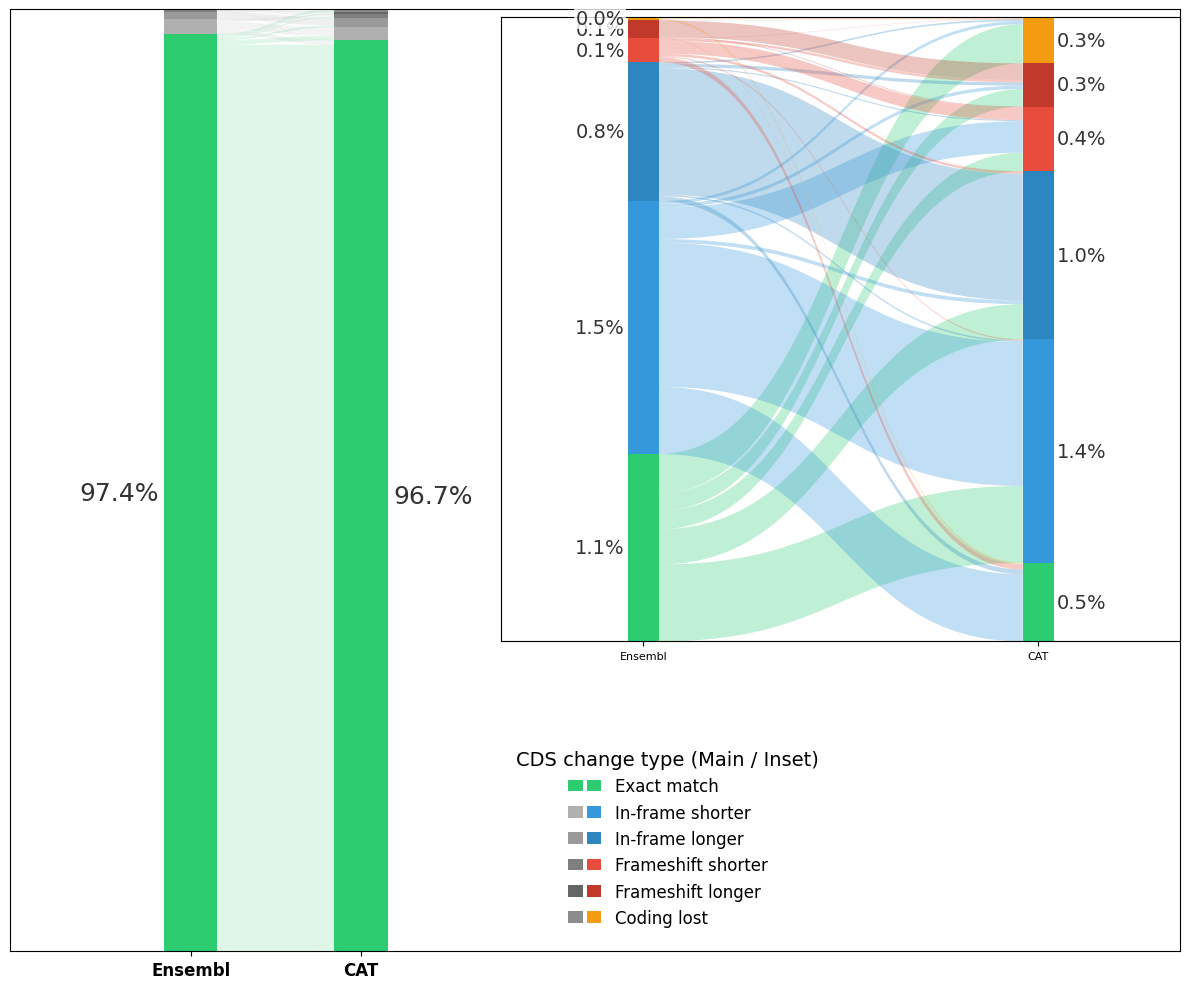

Saved to figures/figure_main2_cds_alluvial_full_greyscale_main_colour_inset.png
Saved to figures/figure_main2_cds_alluvial_full_greyscale_main_colour_inset.pdf


In [6]:
# --- Full alluvial with inset (main greyscale + only label Exact↔Exact; inset full colour + % labels; shared legend in free space; no titles) ---

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# Labels, ordering, colours
# ─────────────────────────────────────────────
GRANULAR_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame shorter',
    'in_frame_longer':    'In-frame longer',
    'frameshift_shorter': 'Frameshift shorter',
    'frameshift_longer':  'Frameshift longer',
    'coding_lost':        'Coding lost',
    'coding_gained':      'Coding gained',
    'non_coding':         'Non-coding',
}
GRANULAR_ORDER = [
    'Exact match',
    'In-frame shorter', 'In-frame longer',
    'Frameshift shorter', 'Frameshift longer',
    'Coding lost', 'Coding gained',
    'Non-coding',
]

# Main: keep exact in green, greyscale the rest (but KEEP separate categories)
MAIN_COLORS = {
    'Exact match':        '#2ecc71',
    'In-frame shorter':   '#b0b0b0',
    'In-frame longer':    '#9a9a9a',
    'Frameshift shorter': '#7f7f7f',
    'Frameshift longer':  '#666666',
    'Coding lost':        '#8c8c8c',
    'Coding gained':      '#737373',
    'Non-coding':         '#c2c2c2',
}

# Inset: colourful palette
INSET_COLORS = {
    'Exact match':        '#2ecc71',
    'In-frame shorter':   '#3498db',
    'In-frame longer':    '#2e86c1',
    'Frameshift shorter': '#e74c3c',
    'Frameshift longer':  '#c0392b',
    'Coding lost':        '#f39c12',
    'Coding gained':      '#d68910',
    'Non-coding':         '#95a5a6',
}

# ─────────────────────────────────────────────
# Load + prepare
# ─────────────────────────────────────────────
ct = pd.read_csv(DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv', sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()
pc['ens_group'] = pc['ens_cds_change_type'].map(GRANULAR_MAP)
pc['cat_group'] = pc['cat_cds_change_type'].map(GRANULAR_MAP)

rows_full = pc.groupby(['ens_group', 'cat_group'], dropna=False)['count'].sum().reset_index()
rows_inset = rows_full[
    ~((rows_full['ens_group'] == 'Exact match') & (rows_full['cat_group'] == 'Exact match'))
].copy()

ens_labels = GRANULAR_ORDER.copy()
cat_labels = GRANULAR_ORDER.copy()

# ─────────────────────────────────────────────
# Alluvial drawing helper
# ─────────────────────────────────────────────
def draw_alluvial(ax, rows, ens_labels, cat_labels, color_map,
                  show_y_labels=True, fontsize_label=8, ribbon_alpha=0.35,
                  x_ens=0.2, x_cat=0.8, bar_w=0.05, label_offset=0.07,
                  label_fmt="{lab}\n{cnt:,} ({pct:.1f}%)",
                  label_bbox=False, min_label_pct=0.0,
                  label_filter=None,
                  percent_denominator=None):
    """
    Draw a two-column alluvial on *ax* and return (ens_ranges, cat_ranges, grand_total).

    percent_denominator:
      - None (default): percentages are relative to this plot's grand_total
      - float: percentages are relative to the provided denominator (e.g. total_full)
    """

    pivot = rows.pivot_table(index='ens_group', columns='cat_group', values='count', fill_value=0)
    pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
    grand_total = float(pivot.values.sum())
    if grand_total == 0:
        return {}, {}, 0

    if percent_denominator is None:
        percent_denominator = grand_total
    percent_denominator = float(percent_denominator) if percent_denominator else grand_total

    def cumulative_ranges(totals, gt):
        rng, cursor = {}, 0.0
        for lab, v in totals.items():
            f = float(v) / gt if gt > 0 else 0.0
            rng[lab] = (cursor, cursor + f)
            cursor += f
        return rng

    ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
    cat_totals = {lab: float(pivot[lab].sum()) if lab in pivot.columns else 0.0 for lab in cat_labels}
    ens_ranges = cumulative_ranges(ens_totals, grand_total)
    cat_ranges = cumulative_ranges(cat_totals, grand_total)

    # Bars
    for lab, (lo, hi) in ens_ranges.items():
        if hi - lo <= 0:
            continue
        ax.bar(x_ens, hi - lo, width=bar_w, bottom=lo,
               color=color_map.get(lab, '#95a5a6'), align='center')

    for lab, (lo, hi) in cat_ranges.items():
        if hi - lo <= 0:
            continue
        ax.bar(x_cat, hi - lo, width=bar_w, bottom=lo,
               color=color_map.get(lab, '#95a5a6'), align='center')

    # Labels
    if show_y_labels:
        bbox = dict(facecolor='white', edgecolor='none', alpha=0.78, pad=0.9) if label_bbox else None

        for lab, (lo, hi) in ens_ranges.items():
            cnt = float(ens_totals[lab])
            if cnt <= 0:
                continue
            pct = cnt / percent_denominator * 100
            if pct < min_label_pct:
                continue
            if label_filter and not label_filter(lab, "ens"):
                continue
            ax.text(x_ens - label_offset, (lo + hi) / 2,
                    label_fmt.format(lab=lab, cnt=int(round(cnt)), pct=pct),
                    ha='right', va='center', fontsize=fontsize_label,
                    color='#333333', bbox=bbox)

        for lab, (lo, hi) in cat_ranges.items():
            cnt = float(cat_totals[lab])
            if cnt <= 0:
                continue
            pct = cnt / percent_denominator * 100
            if pct < min_label_pct:
                continue
            if label_filter and not label_filter(lab, "cat"):
                continue
            ax.text(x_cat + label_offset, (lo + hi) / 2,
                    label_fmt.format(lab=lab, cnt=int(round(cnt)), pct=pct),
                    ha='left', va='center', fontsize=fontsize_label,
                    color='#333333', bbox=bbox)

    # Ribbons (Bezier)
    ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
    cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

    for e in ens_labels:
        for c in cat_labels:
            if e not in pivot.index or c not in pivot.columns:
                continue
            cnt = float(pivot.loc[e, c])
            if cnt <= 0:
                continue
            frac = cnt / grand_total if grand_total > 0 else 0.0

            e_lo = ens_cursor[e]
            e_hi = e_lo + frac
            c_lo = cat_cursor[c]
            c_hi = c_lo + frac
            ens_cursor[e] = e_hi
            cat_cursor[c] = c_hi

            cx = (x_ens + x_cat) / 2.0
            verts = [
                (x_ens + bar_w / 2, e_lo),
                (cx, e_lo), (cx, c_lo), (x_cat - bar_w / 2, c_lo),
                (x_cat - bar_w / 2, c_hi),
                (cx, c_hi), (cx, e_hi), (x_ens + bar_w / 2, e_hi),
                (x_ens + bar_w / 2, e_lo),
            ]
            codes = [
                MplPath.MOVETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.LINETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.CLOSEPOLY,
            ]
            ax.add_patch(PathPatch(
                MplPath(verts, codes),
                facecolor=color_map.get(e, '#95a5a6'),
                edgecolor='none', alpha=ribbon_alpha, zorder=0,
            ))

    return ens_ranges, cat_ranges, grand_total


# ─────────────────────────────────────────────
# Main figure + inset
# ─────────────────────────────────────────────
fig, ax_main = plt.subplots(figsize=(12, 10))

# MAIN: label ONLY Exact match %; make labels closer; lighten grey ribbons
def main_label_filter(lab, side):
    return lab == "Exact match"

ens_r, cat_r, total_full = draw_alluvial(
    ax_main, rows_full, ens_labels, cat_labels, MAIN_COLORS,
    show_y_labels=True,
    fontsize_label=18,        # ↑ larger Exact % labels
    ribbon_alpha=0.15,        # ↓ lighter main ribbons
    x_ens=0.12, x_cat=0.28, bar_w=0.05,
    label_offset=0.03,        # ← move % labels closer to bars
    label_fmt="{pct:.1f}%",
    label_bbox=False,
    label_filter=main_label_filter
)

ax_main.set_xlim(-0.05, 1.05)
ax_main.set_ylim(0, 1)
ax_main.set_xticks([0.12, 0.28])
ax_main.set_xticklabels(['Ensembl', 'CAT'], fontsize=12, fontweight='bold')
ax_main.set_yticks([])

# INSET: right-hand area; full colour palette; show % labels (NOW % of TOTAL, not of inset)
ax_inset = inset_axes(
    ax_main, width="100%", height="92%",
    loc='center right',
    bbox_to_anchor=(0.42, 0.30, 0.58, 0.72),
    bbox_transform=ax_main.transAxes,
    borderpad=0
)

# Use only labels present in disagreement set
inset_labels = [l for l in GRANULAR_ORDER
                if l in rows_inset['ens_group'].values or l in rows_inset['cat_group'].values]

# IMPORTANT: don't drop any % labels
MIN_LABEL_PCT = 0.0

draw_alluvial(
    ax_inset, rows_inset, inset_labels, inset_labels, INSET_COLORS,
    show_y_labels=True, fontsize_label=14.0, ribbon_alpha=0.30,
    x_ens=0.18, x_cat=0.82, bar_w=0.05,
    label_offset=0.03,      # ← move inset % labels closer to bars
    label_fmt="{pct:.1f}%",
    label_bbox=True,
    min_label_pct=MIN_LABEL_PCT,
    percent_denominator=total_full   # ← key change: inset % are of TOTAL
)

ax_inset.set_xlim(-0.05, 1.05)
ax_inset.set_ylim(0, 1)
ax_inset.set_xticks([0.18, 0.82])
ax_inset.set_xticklabels(['Ensembl', 'CAT'], fontsize=8)
ax_inset.set_yticks([])

# Lighten inset border
ax_inset.patch.set_edgecolor('#bbbbbb')
ax_inset.patch.set_linewidth(0.8)

# ─────────────────────────────────────────────
# Shared legend in free space (outside inset), encoding Main (grey) vs Inset (colour)
# Exclude categories with no representation in either plot (zero on both sides)
# ─────────────────────────────────────────────

present = set()

# Anything appearing with nonzero counts in the full dataset
tmp_full = rows_full[rows_full['count'] > 0]
present |= set(tmp_full['ens_group'].dropna().unique())
present |= set(tmp_full['cat_group'].dropna().unique())

# Anything appearing with nonzero counts in the inset dataset (should be subset, but cheap to include)
tmp_inset = rows_inset[rows_inset['count'] > 0]
present |= set(tmp_inset['ens_group'].dropna().unique())
present |= set(tmp_inset['cat_group'].dropna().unique())

legend_labels = [lab for lab in GRANULAR_ORDER if lab in present]

legend_handles = []
legend_text = []
for lab in legend_labels:
    h_main = mpatches.Patch(facecolor=MAIN_COLORS.get(lab, '#95a5a6'), edgecolor='none')
    h_inset = mpatches.Patch(facecolor=INSET_COLORS.get(lab, '#95a5a6'), edgecolor='none')
    legend_handles.append((h_main, h_inset))  # two swatches per entry: Main / Inset
    legend_text.append(lab)

ax_main.legend(
    legend_handles, legend_text,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.25)},
    title="CDS change type (Main / Inset)",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    loc='lower left',
    bbox_to_anchor=(0.42, 0.01)
)
# Dashed highlight box removed

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_main2_cds_alluvial_full_greyscale_main_colour_inset.png',
            dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_main2_cds_alluvial_full_greyscale_main_colour_inset.pdf',
            bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'figure_main2_cds_alluvial_full_greyscale_main_colour_inset.png'}")
print(f"Saved to {OUTPUT_DIR / 'figure_main2_cds_alluvial_full_greyscale_main_colour_inset.pdf'}")